# 04 Backtest and Compare

This notebook compares the static OLS and dynamic Kalman pair models, then backtests both signals on the selected pair.

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [110]:
import importlib
import pipeline_config as cfg

# Reload shared config so notebook picks up edits without a kernel restart.
cfg = importlib.reload(cfg)

BAR_INTERVAL = cfg.BAR_INTERVAL
BAR_INTERVAL_MINUTES = cfg.BAR_INTERVAL_MINUTES
DATA_PATH = cfg.DATA_PATH
ENTRY_Z = cfg.ENTRY_Z
EXIT_Z = cfg.EXIT_Z
PAIR_X = cfg.PAIR_X
PAIR_Y = cfg.PAIR_Y
PERIODS_PER_YEAR = cfg.PERIODS_PER_YEAR
RESULTS_TABLES_PATH = cfg.RESULTS_TABLES_PATH
ROLLING_WINDOW = cfg.ROLLING_WINDOW
WARMUP_BARS = cfg.WARMUP_BARS
ensure_project_dirs = cfg.ensure_project_dirs
make_position = cfg.make_position

ensure_project_dirs()

data_path = DATA_PATH
results_path = RESULTS_TABLES_PATH

In [111]:
pd.Series(
    {
        "pair_y": PAIR_Y,
        "pair_x": PAIR_X,
        "bar_interval": BAR_INTERVAL,
        "bar_interval_minutes": BAR_INTERVAL_MINUTES,
        "rolling_window": ROLLING_WINDOW,
        "warmup_bars": WARMUP_BARS,
        "periods_per_year": PERIODS_PER_YEAR,
    }
)

pair_y                   CVX
pair_x                   XOM
bar_interval              5d
bar_interval_minutes    None
rolling_window            10
warmup_bars               20
periods_per_year        50.4
dtype: object

In [112]:
static_summary = pd.read_csv(results_path / f"{PAIR_Y}_{PAIR_X}_rolling_ols_summary.csv")

static_df = pd.read_csv(
    results_path / f"{PAIR_Y}_{PAIR_X}_rolling_ols.csv",
    index_col=0,
    parse_dates=True,
)
static_df.index.name = "Datetime"

required_static_columns = ["beta", "spread", "zscore"]
assert all(column in static_df.columns for column in required_static_columns)

static_summary

,ticker_y,ticker_x,model_type,alpha,beta,latest_alpha,latest_beta,beta_mean,n_obs_total,n_obs_signal,effective_warmup_bars,rolling_window,entry_z,exit_z,bar_interval,first_signal_timestamp,latest_spread,latest_zscore,spread_adf_pvalue,pair_coint_pvalue
0,CVX,XOM,rolling_ols_lagged,1.131663,0.816427,1.131663,0.816427,0.446223,39,19,20,10,2.0,0.5,5d,2025-11-13,0.032102,0.702413,0.058207,0.727568


In [113]:
dynamic_df = pd.read_csv(
    results_path / f"{PAIR_Y}_{PAIR_X}_kalman_model.csv",
    index_col=0,
    parse_dates=True,
)
dynamic_df.index.name = "Datetime"

required_dynamic_columns = ["alpha", "beta", "spread", "zscore"]
assert all(column in dynamic_df.columns for column in required_dynamic_columns)

dynamic_df.tail()

,y,x,alpha,beta,alpha_pred,beta_pred,innovation,innovation_var,innovation_std,zscore,spread,signal
Datetime,,,,,,,,,,,,
2026-02-26,5.215805,5.000854,1.633655,0.714080,1.633381,0.710737,0.028132,0.000025,0.005031,5.591717,0.011141,-1
2026-03-03,5.240529,5.022761,1.633440,0.716363,1.633655,0.714080,0.020222,0.000029,0.005397,3.747163,0.008967,-1
2026-03-13,5.282290,5.050625,1.632922,0.719199,1.633440,0.716363,0.030767,0.000039,0.006243,4.928079,0.016965,-1
2026-03-18,5.291343,5.059997,1.632699,0.720901,1.632922,0.719199,0.019278,0.000046,0.006768,2.848517,0.010889,-1
2026-03-23,5.323741,5.095344,1.632365,0.722456,1.632699,0.720901,0.017806,0.000051,0.007153,2.489083,0.010213,-1


In [114]:
assert static_df.index.equals(dynamic_df.index)

compare = pd.DataFrame(index=dynamic_df.index)
compare.index.name = "Datetime"
compare["static_beta"] = static_df["beta"]
compare["static_spread"] = static_df["spread"]
compare["static_zscore"] = static_df["zscore"]
compare["dynamic_alpha"] = dynamic_df["alpha"]
compare["dynamic_beta"] = dynamic_df["beta"]
compare["dynamic_spread"] = dynamic_df["spread"]
compare["dynamic_zscore"] = dynamic_df["zscore"]

compare.to_csv(results_path / f"{PAIR_Y}_{PAIR_X}_dynamic_static_compare.csv", index_label="Datetime")
compare.tail()

,static_beta,static_spread,static_zscore,dynamic_alpha,dynamic_beta,dynamic_spread,dynamic_zscore
Datetime,,,,,,,
2026-02-26,0.751651,0.025640,1.095129,1.633655,0.714080,0.011141,5.591717
2026-03-03,0.773831,0.027368,0.959790,1.633440,0.716363,0.008967,3.747163
2026-03-13,0.779513,0.042193,1.368176,1.632922,0.719199,0.016965,4.928079
2026-03-18,0.796607,0.035322,0.848735,1.632699,0.720901,0.010889,2.848517
2026-03-23,0.816427,0.032102,0.702413,1.632365,0.722456,0.010213,2.489083


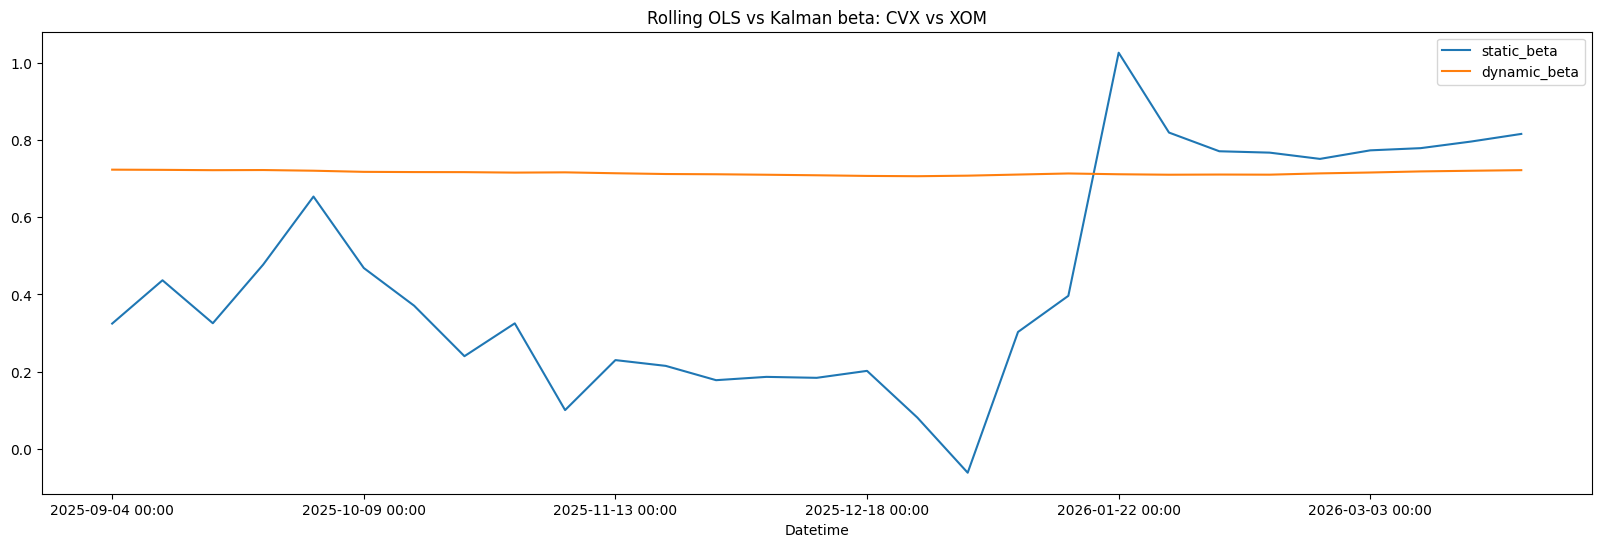

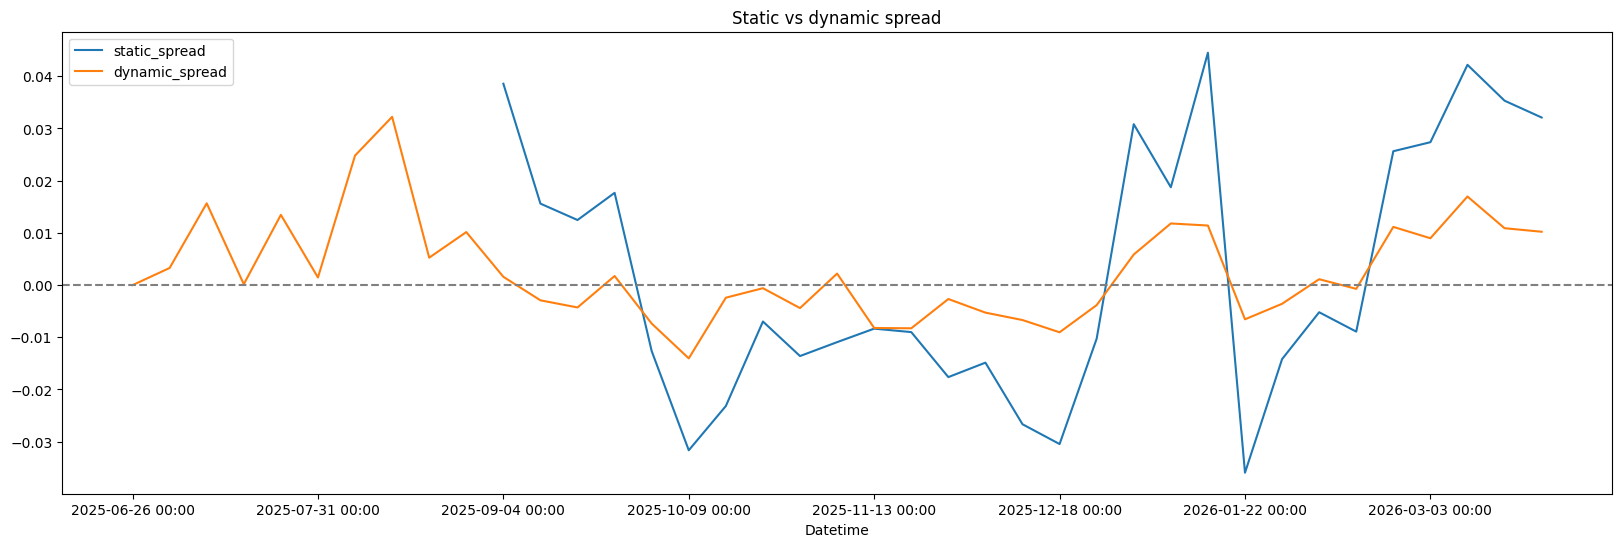

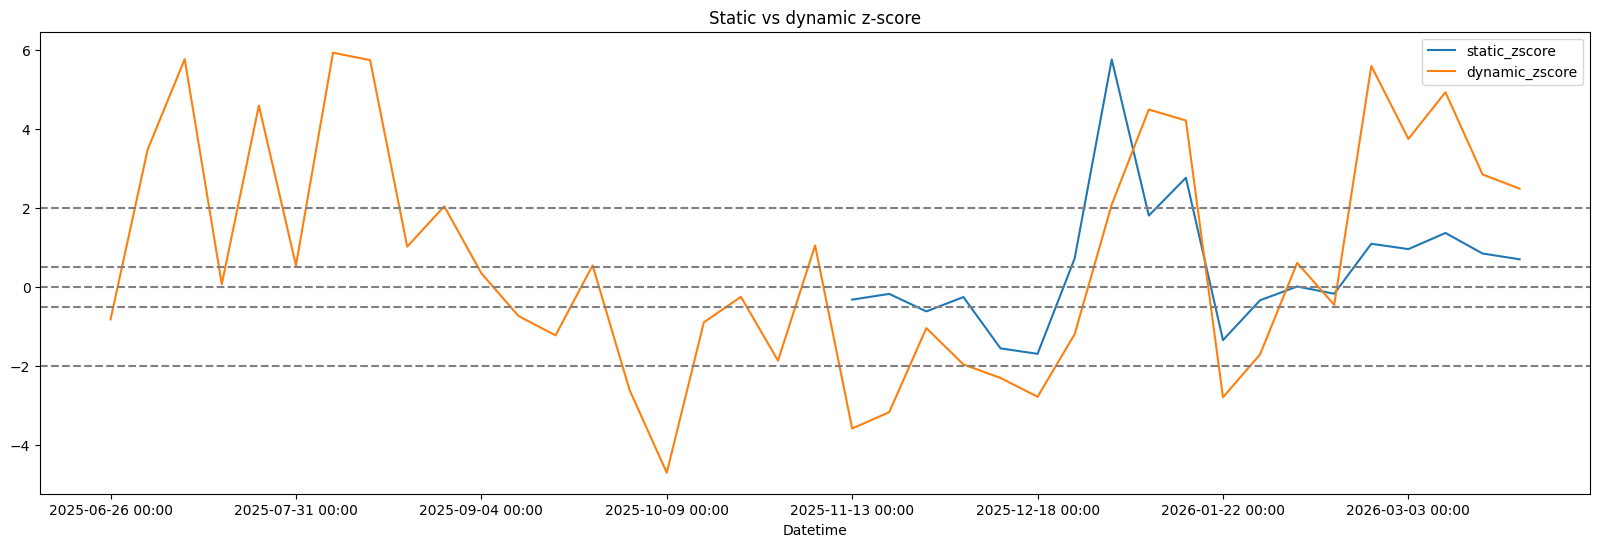

In [115]:
plot_compare = compare.copy()
plot_compare.index = plot_compare.index.strftime("%Y-%m-%d %H:%M")

ax = plot_compare[["static_beta", "dynamic_beta"]].dropna().plot(
    title=f"Rolling OLS vs Kalman beta: {PAIR_Y} vs {PAIR_X}",
    figsize=(20, 6),
)
plt.show()

ax = plot_compare[["static_spread", "dynamic_spread"]].plot(
    title="Static vs dynamic spread",
    figsize=(20, 6),
)
ax.axhline(0, linestyle="--", color="gray")
plt.show()

ax = plot_compare[["static_zscore", "dynamic_zscore"]].plot(
    title="Static vs dynamic z-score",
    figsize=(20, 6),
)
for level in [ENTRY_Z, -ENTRY_Z, EXIT_Z, -EXIT_Z, 0]:
    ax.axhline(level, linestyle="--", color="gray")
plt.show()

In [116]:
prices = pd.read_csv(
    data_path / "equity_prices.csv",
    index_col=0,
    parse_dates=True,
)

pair_prices = prices[[PAIR_Y, PAIR_X]].dropna().copy()
pair_prices.columns = ["price_y", "price_x"]
pair_prices.index.name = "Datetime"

bt = compare.join(pair_prices, how="inner")
bt.index.name = "Datetime"

assert bt.index.is_monotonic_increasing
assert bt.index.is_unique
assert len(bt) > WARMUP_BARS

bt = bt.iloc[WARMUP_BARS:].copy()
bt.tail()

,static_beta,static_spread,static_zscore,dynamic_alpha,dynamic_beta,dynamic_spread,dynamic_zscore,price_y,price_x
Datetime,,,,,,,,,
2026-02-26,0.751651,0.025640,1.095129,1.633655,0.714080,0.011141,5.591717,184.160004,148.539993
2026-03-03,0.773831,0.027368,0.959790,1.633440,0.716363,0.008967,3.747163,188.770004,151.830002
2026-03-13,0.779513,0.042193,1.368176,1.632922,0.719199,0.016965,4.928079,196.820007,156.119995
2026-03-18,0.796607,0.035322,0.848735,1.632699,0.720901,0.010889,2.848517,198.610001,157.589996
2026-03-23,0.816427,0.032102,0.702413,1.632365,0.722456,0.010213,2.489083,205.149994,163.259995


In [117]:
bt["ret_y"] = bt["price_y"].pct_change()
bt["ret_x"] = bt["price_x"].pct_change()

bt.tail()

,static_beta,static_spread,static_zscore,dynamic_alpha,dynamic_beta,dynamic_spread,dynamic_zscore,price_y,price_x,ret_y,ret_x
Datetime,,,,,,,,,,,
2026-02-26,0.751651,0.025640,1.095129,1.633655,0.714080,0.011141,5.591717,184.160004,148.539993,0.000762,-0.038763
2026-03-03,0.773831,0.027368,0.959790,1.633440,0.716363,0.008967,3.747163,188.770004,151.830002,0.025033,0.022149
2026-03-13,0.779513,0.042193,1.368176,1.632922,0.719199,0.016965,4.928079,196.820007,156.119995,0.042645,0.028255
2026-03-18,0.796607,0.035322,0.848735,1.632699,0.720901,0.010889,2.848517,198.610001,157.589996,0.009095,0.009416
2026-03-23,0.816427,0.032102,0.702413,1.632365,0.722456,0.010213,2.489083,205.149994,163.259995,0.032929,0.035979


In [118]:
bt["static_pos"] = make_position(bt["static_zscore"])
bt["dynamic_pos"] = make_position(bt["dynamic_zscore"])

bt[["static_zscore", "static_pos", "dynamic_zscore", "dynamic_pos"]].tail()

,static_zscore,static_pos,dynamic_zscore,dynamic_pos
Datetime,,,,
2026-02-26,1.095129,0,5.591717,-1
2026-03-03,0.959790,0,3.747163,-1
2026-03-13,1.368176,0,4.928079,-1
2026-03-18,0.848735,0,2.848517,-1
2026-03-23,0.702413,0,2.489083,-1


In [119]:
bt["static_pos_lag"] = bt["static_pos"].shift(1)
bt["static_beta_lag"] = bt["static_beta"].shift(1)
bt["dynamic_pos_lag"] = bt["dynamic_pos"].shift(1)
bt["dynamic_beta_lag"] = bt["dynamic_beta"].shift(1)

bt["static_gross_exposure_lag"] = 1 + bt["static_beta_lag"].abs()
bt["static_weight_y_lag"] = bt["static_pos_lag"] / bt["static_gross_exposure_lag"]
bt["static_weight_x_lag"] = -bt["static_pos_lag"] * bt["static_beta_lag"] / bt["static_gross_exposure_lag"]

bt["dynamic_gross_exposure_lag"] = 1 + bt["dynamic_beta_lag"].abs()
bt["dynamic_weight_y_lag"] = bt["dynamic_pos_lag"] / bt["dynamic_gross_exposure_lag"]
bt["dynamic_weight_x_lag"] = -bt["dynamic_pos_lag"] * bt["dynamic_beta_lag"] / bt["dynamic_gross_exposure_lag"]

In [120]:
bt["static_ret_gross"] = (
    bt["static_weight_y_lag"] * bt["ret_y"] + bt["static_weight_x_lag"] * bt["ret_x"]
)
bt["dynamic_ret_gross"] = (
    bt["dynamic_weight_y_lag"] * bt["ret_y"] + bt["dynamic_weight_x_lag"] * bt["ret_x"]
)

cost_bps = 5 / 10000

bt["static_gross_exposure"] = 1 + bt["static_beta"].abs()
bt["static_weight_y"] = bt["static_pos"] / bt["static_gross_exposure"]
bt["static_weight_x"] = -bt["static_pos"] * bt["static_beta"] / bt["static_gross_exposure"]

bt["dynamic_gross_exposure"] = 1 + bt["dynamic_beta"].abs()
bt["dynamic_weight_y"] = bt["dynamic_pos"] / bt["dynamic_gross_exposure"]
bt["dynamic_weight_x"] = -bt["dynamic_pos"] * bt["dynamic_beta"] / bt["dynamic_gross_exposure"]

bt["static_turnover"] = (
    bt["static_weight_y"].diff().abs().fillna(bt["static_weight_y"].abs())
    + bt["static_weight_x"].diff().abs().fillna(bt["static_weight_x"].abs())
)
bt["dynamic_turnover"] = (
    bt["dynamic_weight_y"].diff().abs().fillna(bt["dynamic_weight_y"].abs())
    + bt["dynamic_weight_x"].diff().abs().fillna(bt["dynamic_weight_x"].abs())
)

bt["static_cost"] = cost_bps * bt["static_turnover"]
bt["dynamic_cost"] = cost_bps * bt["dynamic_turnover"]
bt["static_ret_net"] = bt["static_ret_gross"] - bt["static_cost"]
bt["dynamic_ret_net"] = bt["dynamic_ret_gross"] - bt["dynamic_cost"]

bt[["static_ret_net", "dynamic_ret_net"]].tail()

,static_ret_net,dynamic_ret_net
Datetime,,
2026-02-26,0.0,-0.000500
2026-03-03,0.0,-0.005378
2026-03-13,0.0,-0.013054
2026-03-18,0.0,-0.001352
2026-03-23,0.0,-0.004063


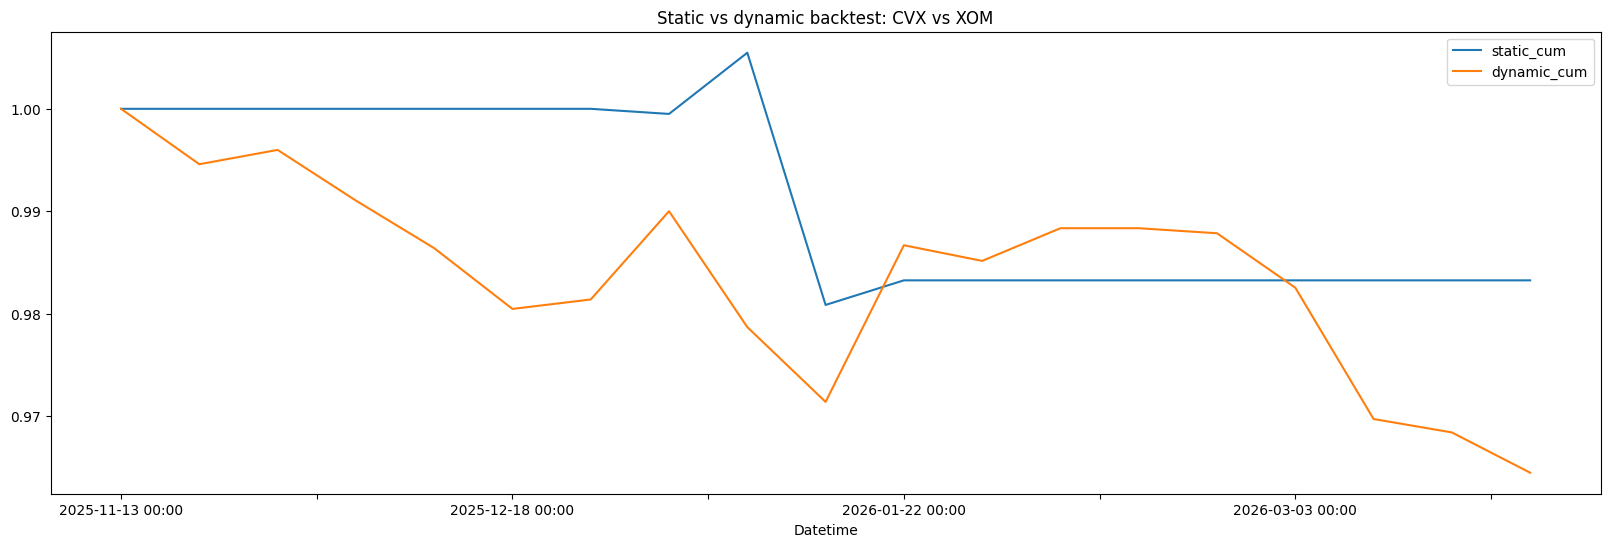

In [121]:
bt["static_cum"] = (1 + bt["static_ret_net"].fillna(0)).cumprod()
bt["dynamic_cum"] = (1 + bt["dynamic_ret_net"].fillna(0)).cumprod()

plot_bt = bt[["static_cum", "dynamic_cum"]].copy()
plot_bt.index = plot_bt.index.strftime("%Y-%m-%d %H:%M")
plot_bt.plot(title=f"Static vs dynamic backtest: {PAIR_Y} vs {PAIR_X}", figsize=(20, 6))
plt.show()

In [122]:
def performance_summary(returns, periods_per_year=PERIODS_PER_YEAR):
    returns = returns.dropna()

    ann_return = returns.mean() * periods_per_year
    ann_vol = returns.std() * np.sqrt(periods_per_year)

    if ann_vol == 0:
        sharpe = np.nan
    else:
        sharpe = ann_return / ann_vol

    cum = (1 + returns).cumprod()
    drawdown = cum / cum.cummax() - 1
    max_dd = drawdown.min()

    return pd.Series(
        {
            "return": ann_return,
            "vol": ann_vol,
            "sharpe": sharpe,
            "max_drawdown": max_dd,
            "n": len(returns),
        }
    )

In [123]:
backtest_summary = pd.DataFrame(
    {
        "static_ols": performance_summary(bt["static_ret_net"]),
        "dynamic_kalman": performance_summary(bt["dynamic_ret_net"]),
    }
).T

backtest_summary

,return,vol,sharpe,max_drawdown,n
static_ols,-0.046389,0.043105,-1.076186,-0.024494,18.0
dynamic_kalman,-0.100114,0.048278,-2.073692,-0.031650,18.0


In [124]:
bt.to_csv(results_path / f"{PAIR_Y}_{PAIR_X}_static_vs_dynamic_backtest.csv", index_label="Datetime")
backtest_summary.to_csv(results_path / f"{PAIR_Y}_{PAIR_X}_backtest_summary.csv", index_label="strategy")